In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
customers_df = pd.read_excel('../Datasets/customer_data.xlsx')
customers_df.head(5)

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05,Yes
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08,Yes
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30,No
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01,No
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23,No


In [4]:
missing_values = customers_df.isnull().sum()
print('missing values in each column:\n', missing_values)


missing values in each column:
 CustomerID                  0
Gender                      0
Age                         0
Income                      5
City                        3
Region                      0
Frequency_of_Purchases      0
Average_Purchase_Amount     0
Customer_Lifespan_Months    0
Purchase_Channel            0
Date_of_Purchase            0
Churn_Status                0
dtype: int64


In [5]:
from sklearn.impute import SimpleImputer

In [6]:
imputer = SimpleImputer(strategy='median')   
imputer_2 = SimpleImputer(strategy='most_frequent')

customers_df['Income'] = imputer.fit_transform(customers_df[['Income']])[:,0]
customers_df['City'] = imputer_2.fit_transform(customers_df[['City']])[:,0]


In [7]:
missing_values = customers_df.isnull().sum()
print('missing values in each column:\n', missing_values)

missing values in each column:
 CustomerID                  0
Gender                      0
Age                         0
Income                      0
City                        0
Region                      0
Frequency_of_Purchases      0
Average_Purchase_Amount     0
Customer_Lifespan_Months    0
Purchase_Channel            0
Date_of_Purchase            0
Churn_Status                0
dtype: int64


In [8]:
customers_df['Customer_Lifespan_Months'].unique()

array([3, 4, 1, 2, 5, 'XXXX'], dtype=object)

In [9]:
customers_df = customers_df[customers_df['Customer_Lifespan_Months'] != 'XXXX']
customers_df['Customer_Lifespan_Months'].unique()

array([3, 4, 1, 2, 5], dtype=object)

In [10]:
customers_df['Customer_Lifespan_Months'] = customers_df['Customer_Lifespan_Months'].astype(int)
customers_df['Date_of_Purchase'] = customers_df['Date_of_Purchase'].astype('datetime64[ns]')
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 0 to 80
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CustomerID                80 non-null     object        
 1   Gender                    80 non-null     object        
 2   Age                       80 non-null     int64         
 3   Income                    80 non-null     float64       
 4   City                      80 non-null     object        
 5   Region                    80 non-null     object        
 6   Frequency_of_Purchases    80 non-null     int64         
 7   Average_Purchase_Amount   80 non-null     float64       
 8   Customer_Lifespan_Months  80 non-null     int64         
 9   Purchase_Channel          80 non-null     object        
 10  Date_of_Purchase          80 non-null     datetime64[ns]
 11  Churn_Status              80 non-null     object        
dtypes: datetime64[ns](1), float64

In [11]:
dup_cus = customers_df.duplicated()
customers_df[dup_cus]

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
80,C021,Female,22,41743.0,Los Angeles,Northeast,4,54.599,1,Online,2023-06-08,No


In [12]:
customers_df.drop_duplicates(inplace=True)
customers_df[dup_cus]

C:\Users\thapa\AppData\Local\Temp\ipykernel_5132\1656588182.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  customers_df[dup_cus]


,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status


In [13]:
sorted_df = customers_df.sort_values(by='Income', ascending=False)
sorted_df.head(5)

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
55,C056,Female,29,107662.0,Houston,Northeast,3,47.877,1,In-store,2022-02-11,No
22,C023,Female,41,105186.0,Los Angeles,Midwest,14,137.697,4,Online,2023-07-15,Yes
70,C071,Female,36,103264.0,Los Angeles,Northeast,11,117.394,3,Online,2023-12-22,Yes
32,C033,Female,31,98590.0,Houston,West,7,76.114,2,Online,2023-06-30,No
52,C053,Female,45,90860.0,Houston,Northeast,10,105.287,3,In-store,2023-12-29,Yes


In [14]:
customers_df.loc[0:5, 'CustomerID':'Region']

,CustomerID,Gender,Age,Income,City,Region
0,C001,Male,49,72504.0,Chicago,Northeast
1,C002,Female,38,40881.0,New York,West
2,C003,Male,17,63333.0,New York,Northeast
3,C004,Male,34,58030.0,Chicago,Midwest
4,C005,Male,30,78889.0,Houston,Midwest
5,C006,Male,52,76470.0,Chicago,Midwest


In [15]:
customers_df.iloc[0:5, 0:5] 

,CustomerID,Gender,Age,Income,City
0,C001,Male,49,72504.0,Chicago
1,C002,Female,38,40881.0,New York
2,C003,Male,17,63333.0,New York
3,C004,Male,34,58030.0,Chicago
4,C005,Male,30,78889.0,Houston


In [16]:
male_customers = customers_df[customers_df['Gender'] == 'Male']
print(male_customers.head(5))

  CustomerID Gender  Age   Income      City     Region  \
0       C001   Male   49  72504.0   Chicago  Northeast   
2       C003   Male   17  63333.0  New York  Northeast   
3       C004   Male   34  58030.0   Chicago    Midwest   
4       C005   Male   30  78889.0   Houston    Midwest   
5       C006   Male   52  76470.0   Chicago    Midwest   

   Frequency_of_Purchases  Average_Purchase_Amount  Customer_Lifespan_Months  \
0                      10                   98.241                         3   
2                       1                   41.252                         1   
3                       6                   67.329                         1   
4                       3                   52.763                         1   
5                      11                  117.012                         3   

  Purchase_Channel Date_of_Purchase Churn_Status  
0           Online       2022-03-05          Yes  
2           Online       2023-01-30           No  
3         In-stor

In [17]:
Freq_male = male_customers[male_customers['Frequency_of_Purchases'] > 5 ]
print(Freq_male.head(5))

  CustomerID Gender  Age   Income         City     Region  \
0       C001   Male   49  72504.0      Chicago  Northeast   
3       C004   Male   34  58030.0      Chicago    Midwest   
5       C006   Male   52  76470.0      Chicago    Midwest   
7       C008   Male   38  38401.0      Houston       West   
8       C009   Male   44  73105.0  Los Angeles  Northeast   

   Frequency_of_Purchases  Average_Purchase_Amount  Customer_Lifespan_Months  \
0                      10                   98.241                         3   
3                       6                   67.329                         1   
5                      11                  117.012                         3   
7                       6                   70.730                         2   
8                      12                  124.887                         3   

  Purchase_Channel Date_of_Purchase Churn_Status  
0           Online       2022-03-05          Yes  
3         In-store       2023-06-01           No  

In [18]:
performance_df = pd.read_excel('../Datasets/performance_data.xlsx')
performance_df.head(5)

,CustomerID,Recency,Frequency_Score,Monetary_Score
0,C001,3,2,2
1,C002,3,3,3
2,C003,4,4,4
3,C004,2,2,2
4,C005,1,1,1


In [19]:
joined_df = customers_df.merge(performance_df, on='CustomerID', how='inner')
joined_df.head(5)

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05,Yes,3,2,2
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08,Yes,3,3,3
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30,No,4,4,4
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01,No,2,2,2
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23,No,1,1,1


In [20]:
additional_data_df = pd.read_excel('../Datasets/additional_data.xlsx')
additional_data_df.head(5)

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,CustomerID.1,Recency,Frequency_Score,Monetary_Score
0,C081,Male,37,50728,Chicago,West,11,75.757,2,In-store,2023-09-10,Yes,C081,2,2,1
1,C082,Female,48,69629,Los Angeles,Midwest,9,78.433,4,In-store,2023-07-15,No,C082,3,4,4
2,C083,Male,28,29184,Chicago,Northeast,7,82.794,3,Online,2023-08-25,Yes,C083,3,1,2
3,C084,Female,33,61265,Los Angeles,West,15,88.490,2,Online,2022-10-22,Yes,C084,4,1,3
4,C085,Female,30,63130,Houston,Midwest,13,108.749,3,Online,2023-04-01,Yes,C085,4,4,1


In [21]:
final_df = pd.concat([joined_df.reset_index(drop=True), additional_data_df.reset_index(drop=True)])
final_df.head(5)

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score,CustomerID.1
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05 00:00:00,Yes,3,2,2,NaN
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08 00:00:00,Yes,3,3,3,NaN
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30 00:00:00,No,4,4,4,NaN
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01 00:00:00,No,2,2,2,NaN
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23 00:00:00,No,1,1,1,NaN


In [22]:
final_df = (final_df.drop(columns=['CustomerID.1'], axis=1))
final_df.head(5)

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05 00:00:00,Yes,3,2,2
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08 00:00:00,Yes,3,3,3
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30 00:00:00,No,4,4,4
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01 00:00:00,No,2,2,2
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23 00:00:00,No,1,1,1


In [23]:
freq_purchase_channel = final_df['Purchase_Channel'].value_counts()
freq_purchase_channel

Purchase_Channel
Online      65
In-store    34
Name: count, dtype: int64

In [24]:
Perc_purchase_channel = freq_purchase_channel / len(final_df) * 100
Perc_purchase_channel

Purchase_Channel
Online      65.656566
In-store    34.343434
Name: count, dtype: float64

In [25]:
round(final_df.describe())

,Age,Income,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Recency,Frequency_Score,Monetary_Score
count,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0
mean,35.0,58115.0,9.0,135687.0,3.0,3.0,3.0,3.0
std,10.0,18618.0,3.0,1349094.0,1.0,1.0,1.0,1.0
min,17.0,15531.0,1.0,37.0,0.0,1.0,1.0,1.0
25%,28.0,45724.0,7.0,76.0,2.0,2.0,2.0,2.0
50%,35.0,58033.0,10.0,98.0,3.0,3.0,3.0,3.0
75%,42.0,71484.0,12.0,121.0,3.0,4.0,4.0,4.0
max,54.0,107662.0,16.0,13423412.0,5.0,4.0,4.0,4.0


In [26]:
final_df = final_df[final_df['Average_Purchase_Amount'] != 13423411.958]

In [27]:
round(final_df.describe())

,Age,Income,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Recency,Frequency_Score,Monetary_Score
count,98.0,98.0,98.0,98.0,98.0,98.0,98.0,98.0
mean,35.0,58131.0,9.0,98.0,3.0,3.0,3.0,3.0
std,10.0,18713.0,3.0,29.0,1.0,1.0,1.0,1.0
min,17.0,15531.0,1.0,37.0,0.0,1.0,1.0,1.0
25%,28.0,45482.0,7.0,76.0,2.0,2.0,2.0,2.0
50%,35.0,58033.0,10.0,97.0,3.0,3.0,3.0,3.0
75%,42.0,71994.0,12.0,120.0,3.0,4.0,4.0,4.0
max,54.0,107662.0,16.0,193.0,5.0,4.0,4.0,4.0


In [28]:
city_purchase_amount = final_df.groupby('City')['Average_Purchase_Amount'].median()
city_purchase_amount

City
Chicago        102.1860
Houston         87.6615
Los Angeles    100.7250
New York        94.4690
Name: Average_Purchase_Amount, dtype: float64

In [29]:
pivot_table = final_df.pivot_table(index = 'Churn_Status', 
                                     values = ['Recency', 'Frequency_Score', 'Monetary_Score'], 
                                     aggfunc = {'Recency':'mean', 'Frequency_Score':'mean', 'Monetary_Score':'mean', 'Churn_Status':'count'})

In [30]:
pivot_table = pivot_table.rename(columns = {'Churn_Status':'Freq_churn', 
                                            'Recency':'Mean_recency', 
                                            'Frequency_Score':'Mean_FS', 'Monetary_Score':'Mean_MS'})

pivot_table


,Freq_churn,Mean_FS,Mean_MS,Mean_recency
Churn_Status,,,,
No,43,2.744186,2.558140,2.720930
Yes,55,2.509091,2.509091,2.618182


In [31]:
cross_tab = pd.crosstab(final_df['City'], final_df['Churn_Status'])
cross_tab

Churn_Status,No,Yes
City,,
Chicago,8,17
Houston,16,16
Los Angeles,10,14
New York,9,8


In [32]:
num_variables = final_df.select_dtypes(include = ['number']).columns
correl = round(final_df[num_variables].corr(), 3)
correl


,Age,Income,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Recency,Frequency_Score,Monetary_Score
Age,1.000,0.110,0.301,0.170,0.334,-0.048,-0.006,0.065
Income,0.110,1.000,-0.022,0.023,0.068,0.178,0.163,0.162
Frequency_of_Purchases,0.301,-0.022,1.000,0.704,0.762,-0.063,-0.065,-0.066
Average_Purchase_Amount,0.170,0.023,0.704,1.000,0.690,-0.029,-0.145,-0.191
Customer_Lifespan_Months,0.334,0.068,0.762,0.690,1.000,-0.073,-0.013,-0.001
Recency,-0.048,0.178,-0.063,-0.029,-0.073,1.000,0.761,0.743
Frequency_Score,-0.006,0.163,-0.065,-0.145,-0.013,0.761,1.000,0.819
Monetary_Score,0.065,0.162,-0.066,-0.191,-0.001,0.743,0.819,1.000


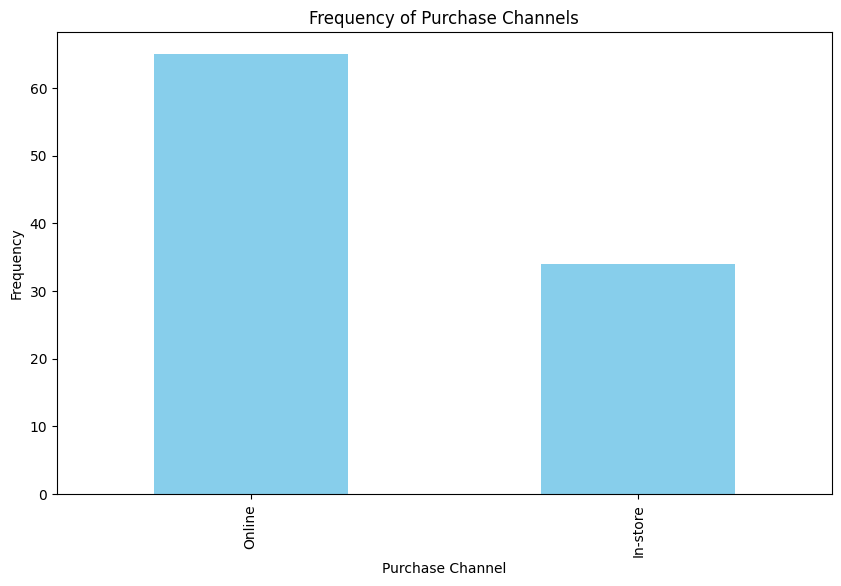

In [33]:
plt.figure(figsize=(10,6))
freq_purchase_channel.plot(kind='bar', color='skyblue')
plt.title('Frequency of Purchase Channels')
plt.xlabel('Purchase Channel')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

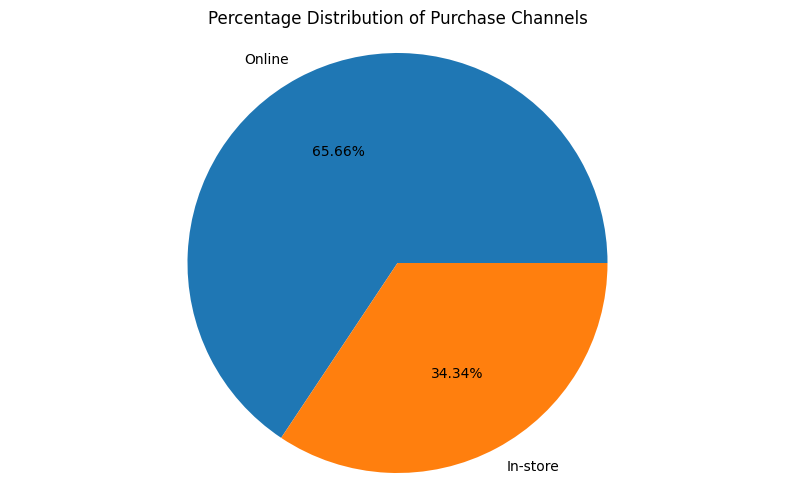

In [34]:
plt.figure(figsize=(10,6))
plt.pie(Perc_purchase_channel, labels=Perc_purchase_channel.index, autopct='%1.2f%%')
plt.title('Percentage Distribution of Purchase Channels')
plt.axis('equal')
plt.show()

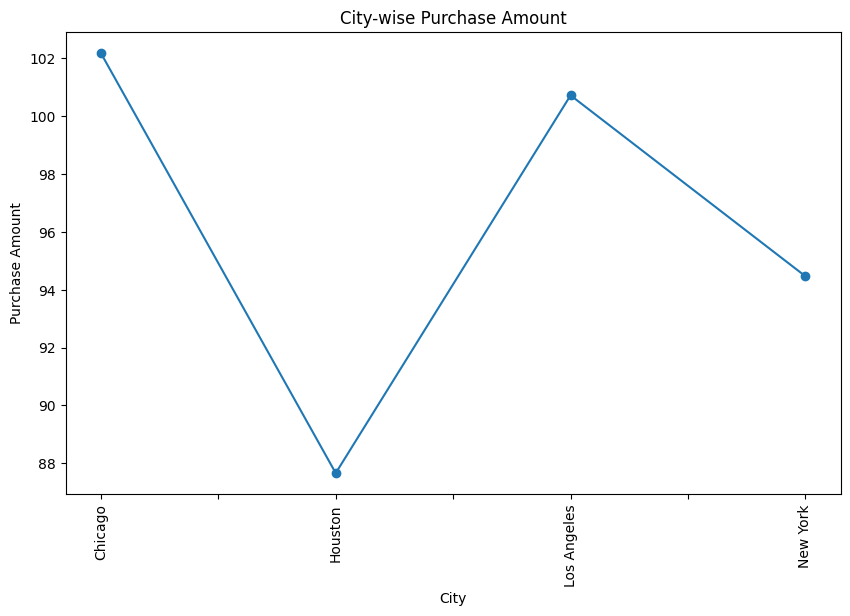

In [35]:
plt.figure(figsize=(10,6))
city_purchase_amount.plot(kind='line', marker='o')
plt.title('City-wise Purchase Amount')
plt.xlabel('City')
plt.ylabel('Purchase Amount')
plt.xticks(rotation=90)
plt.show()

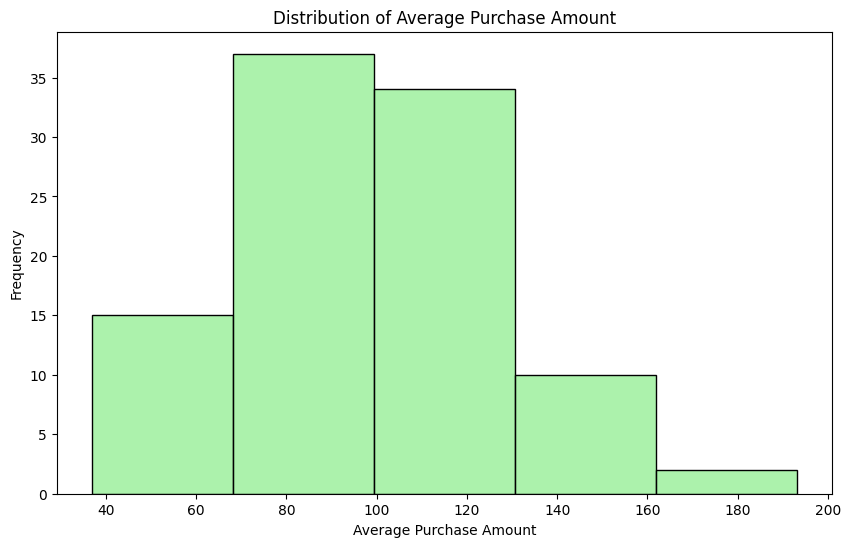

In [36]:
plt.figure(figsize=(10,6))
sns.histplot(final_df['Average_Purchase_Amount'], bins=5, color='lightgreen')
plt.title('Distribution of Average Purchase Amount')
plt.xlabel('Average Purchase Amount')
plt.ylabel('Frequency')
plt.show()

<Figure size 1000x600 with 0 Axes>

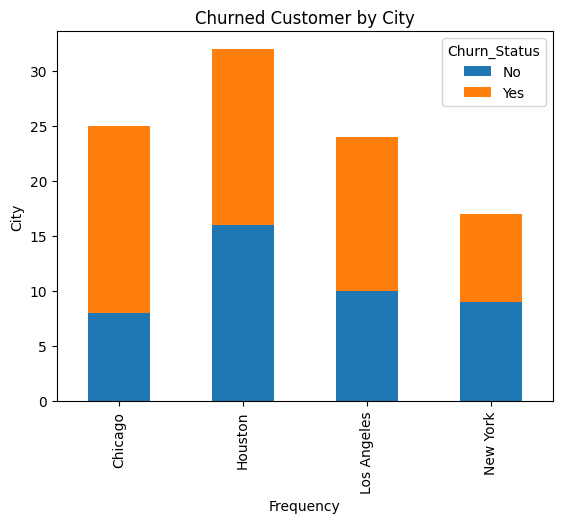

In [37]:
plt.figure(figsize= (10,6))
cross_tab.plot(kind = 'bar', stacked=True)
plt.title('Churned Customer by City')
plt.xlabel('Frequency')
plt.ylabel('City')
plt.show()


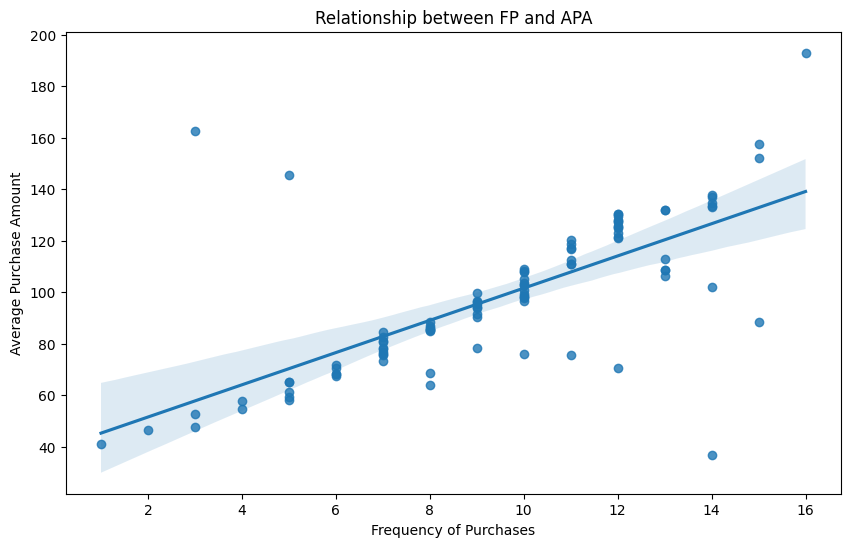

In [38]:
plt.figure(figsize = (10, 6))
sns.regplot(x = 'Frequency_of_Purchases', y = 'Average_Purchase_Amount', data = final_df)
plt.title('Relationship between FP and APA')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Average Purchase Amount')
plt.show()

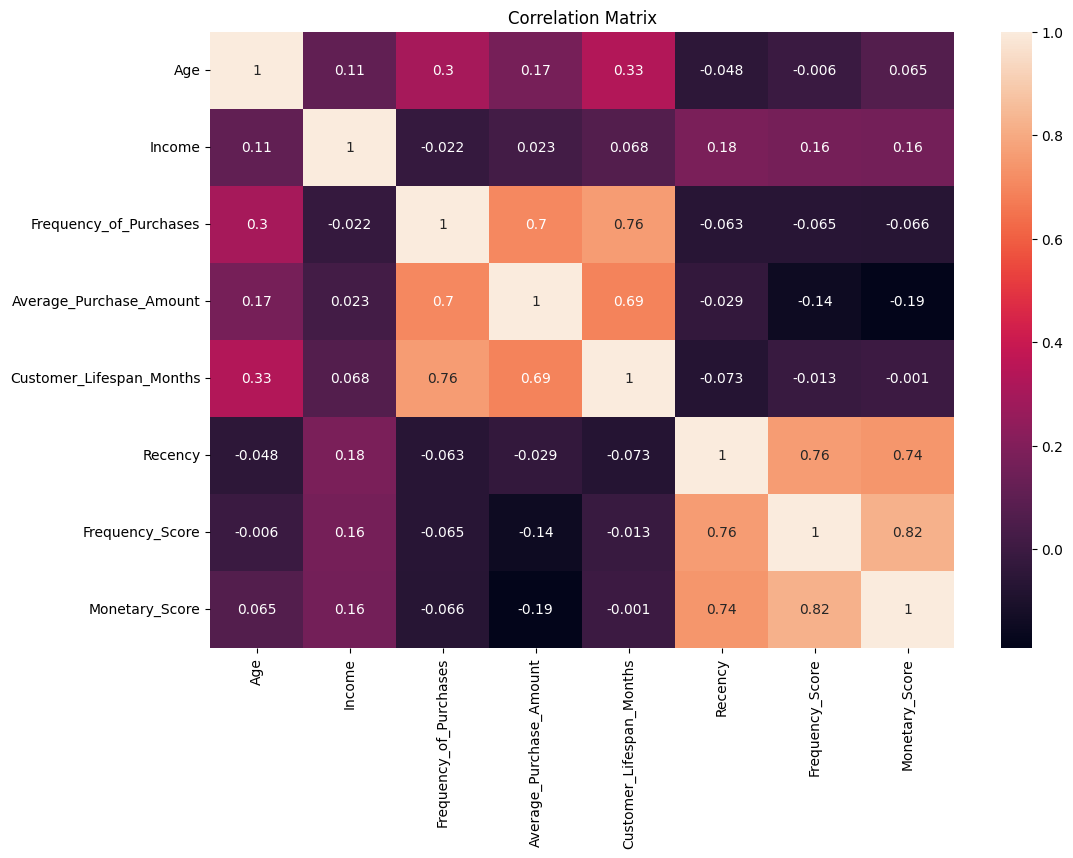

In [39]:
plt.figure(figsize = (12, 8))
sns.heatmap(correl, annot = True)
plt.title('Correlation Matrix')
plt.show()

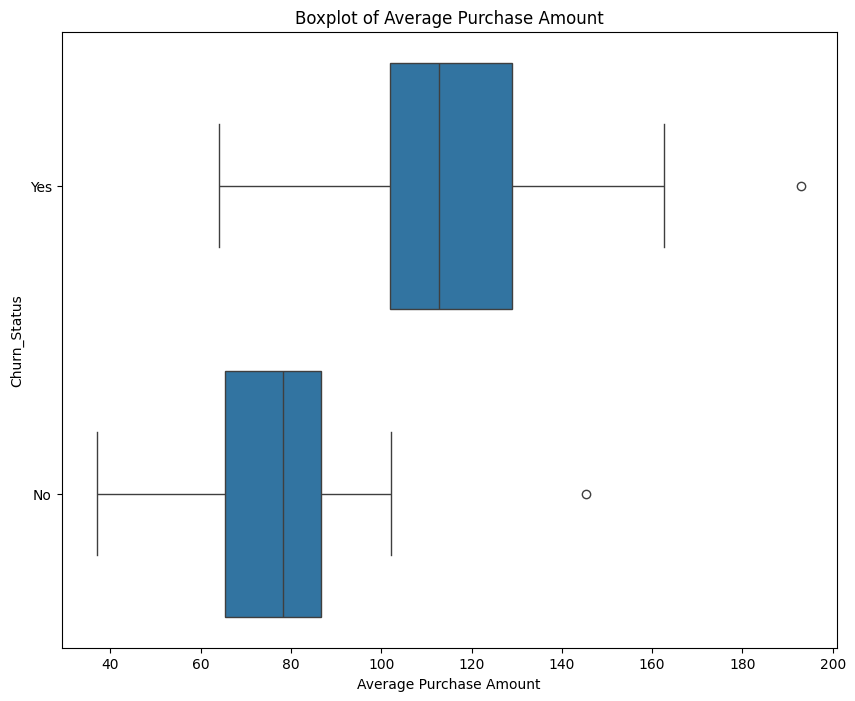

In [40]:
plt.figure(figsize = (10, 8))
sns.boxplot(x = 'Average_Purchase_Amount', y = 'Churn_Status', data = final_df)
plt.title('Boxplot of Average Purchase Amount')
plt.xlabel('Average Purchase Amount')
plt.show()

In [41]:
from scipy.stats import shapiro

In [42]:
final_df.describe()

,Age,Income,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Recency,Frequency_Score,Monetary_Score
count,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000
mean,35.030612,58130.979592,9.428571,98.052806,2.540816,2.663265,2.612245,2.530612
std,9.850903,18712.728227,3.264934,29.009387,1.017054,1.139215,1.108846,1.114146
min,17.000000,15531.000000,1.000000,36.975000,0.000000,1.000000,1.000000,1.000000
25%,28.000000,45481.500000,7.000000,76.292000,2.000000,2.000000,2.000000,2.000000
50%,35.000000,58033.000000,10.000000,97.167500,3.000000,3.000000,3.000000,3.000000
75%,41.750000,71994.250000,12.000000,119.878000,3.000000,4.000000,4.000000,3.750000
max,54.000000,107662.000000,16.000000,193.046000,5.000000,4.000000,4.000000,4.000000


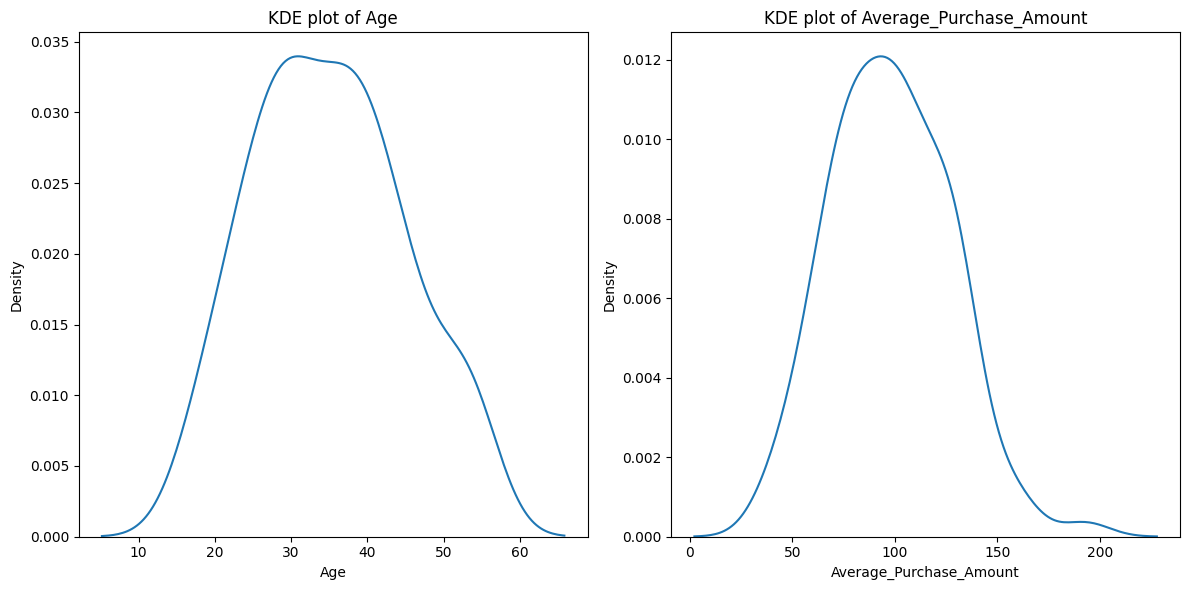

In [43]:
numeric_columns = ['Age', 'Average_Purchase_Amount']

fig, axes = plt.subplots(1, 2, figsize = (12, 6))

for index, column in enumerate(numeric_columns):
    sns.kdeplot(final_df[column], ax = axes[index])
    axes[index].set_title(f'KDE plot of {column}')
    
plt.tight_layout()
plt.show()

In [44]:
shapiro_results = {}
for column in numeric_columns:
    stat,p_value = shapiro(final_df[column])
    shapiro_results[column] = round(p_value, 3)
    
shapiro_results
    

{'Age': np.float64(0.037), 'Average_Purchase_Amount': np.float64(0.487)}

In [45]:
def sqrt_transform(data,column_name):
    data[f'{column_name}_sqrt'] = np.sqrt(data[column_name])
    stat,P_value = shapiro(data[f'{column_name}_sqrt'])
    distribution = sns.kdeplot(data[f'{column_name}_sqrt'])
    print(distribution)
    print('p-value:', p_value)
    

Axes(0.125,0.11;0.775x0.77)
p-value: 0.4873337102625166


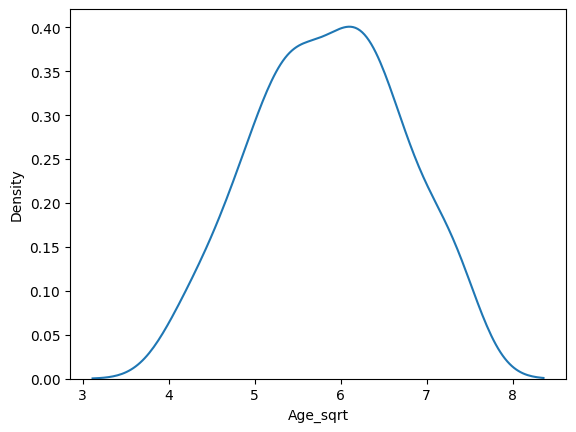

In [46]:
sqrt_transform(final_df, 'Age')

In [47]:
def log_transform(data,column_name):
    data[f'{column_name}_log'] = np.log(data[column_name])
    stat,P_value = shapiro(data[f'{column_name}_log'])
    distribution = sns.kdeplot(data[f'{column_name}_log'])
    print(distribution)
    print('p-value:', p_value)

Axes(0.125,0.11;0.775x0.77)
p-value: 0.4873337102625166


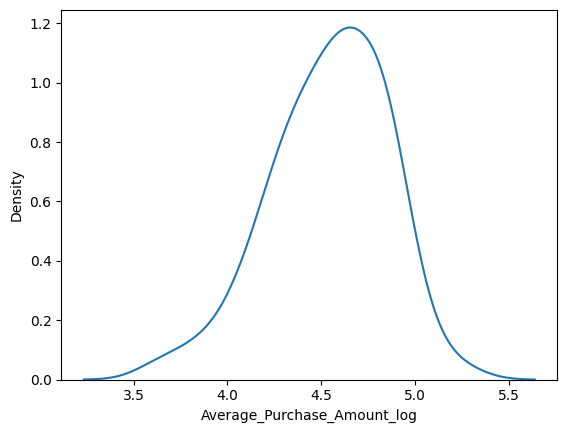

In [48]:
log_transform(final_df, 'Average_Purchase_Amount')

In [49]:
from scipy.stats import boxcox
    
def boxcox_transformation(data, column_name):
    transformed_data, _ = boxcox(data[column_name])
    data[f'{column_name}_boxcox'] = transformed_data
    stat, p_value = shapiro(data[f'{column_name}_boxcox'])
    kdeplot = sns.kdeplot(data[f'{column_name}_boxcox'])
    
    print(kdeplot)
    print('P value: ', p_value)

Axes(0.125,0.11;0.775x0.77)
P value:  0.0980634621204454


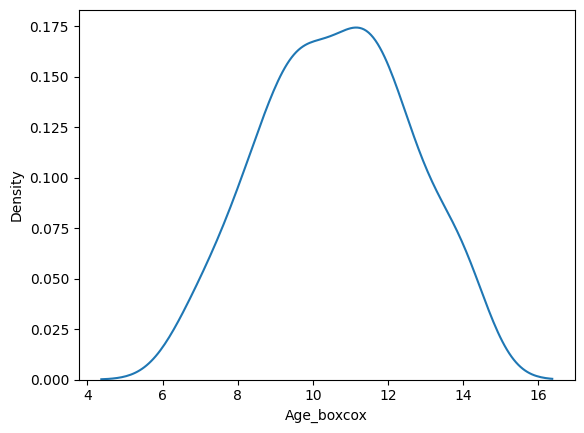

In [50]:
boxcox_transformation(final_df, 'Age')

In [51]:
from scipy.stats import yeojohnson

def yeojohnson_transformation(data, column_name):
    transformed_data, _ = yeojohnson(data[column_name])
    data[f'{column_name}_yeojohnson'] = transformed_data
    stat, p_value = shapiro(data[f'{column_name}_yeojohnson'])
    kdeplot = sns.kdeplot(data[f'{column_name}_yeojohnson'])
    
    print(kdeplot)
    print('P value: ', p_value)

Axes(0.125,0.11;0.775x0.77)
P value:  0.09733558153015867


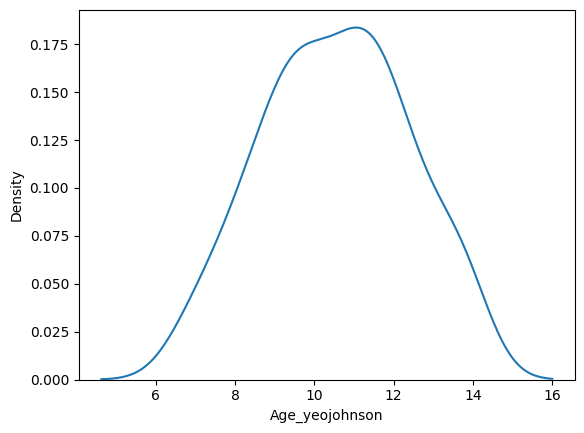

In [52]:
yeojohnson_transformation(final_df,'Age')


In [53]:
from scipy import stats
preprocessed_data = final_df.drop(['Age', 'Age_boxcox', 'Age_yeojohnson'], axis = 1)
preprocessed_data.head()


,CustomerID,Gender,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score,Age_sqrt,Average_Purchase_Amount_log
0,C001,Male,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05 00:00:00,Yes,3,2,2,7.000000,4.587424
1,C002,Female,40881.0,New York,West,15,157.640,4,In-store,2023-07-08 00:00:00,Yes,3,3,3,6.164414,5.060314
2,C003,Male,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30 00:00:00,No,4,4,4,4.123106,3.719700
3,C004,Male,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01 00:00:00,No,2,2,2,5.830952,4.209591
4,C005,Male,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23 00:00:00,No,1,1,1,5.477226,3.965810


In [54]:
churned_customers = preprocessed_data.query('Churn_Status == "Yes"')['Average_Purchase_Amount']
existing_customers = preprocessed_data.query('Churn_Status == "No"')['Average_Purchase_Amount']

t_stat,P_value = stats.ttest_ind(churned_customers, existing_customers)
print('p-value:', P_value)

if P_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in Average Purchase Amount between churned and existing customers.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in Average Purchase Amount")

p-value: 1.0775507203194482e-13
Reject the null hypothesis: There is a significant difference in Average Purchase Amount between churned and existing customers.


In [55]:
churned_customers.mean()


np.float64(114.96134545454547)

In [56]:
existing_customers.mean()

np.float64(76.42560465116279)

In [57]:
stat, p_value = shapiro(preprocessed_data['Frequency_of_Purchases'])
print(p_value)

0.11246168308148519


In [58]:
chicago_cust = preprocessed_data.query('City == "Chicago"')['Frequency_of_Purchases']
newyork_cust = preprocessed_data.query('City == "New York"')['Frequency_of_Purchases']
houston_cust = preprocessed_data.query('City == "Houston"')['Frequency_of_Purchases']
losangeles_cust = preprocessed_data.query('City == "Los Angeles"')['Frequency_of_Purchases']

Test_stat, p_value = stats.f_oneway(chicago_cust, newyork_cust, houston_cust, losangeles_cust)
print("P value: ", p_value)

if p_value < 0.05:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

P value:  0.09375619087069023
Fail to reject the null hypothesis


In [59]:
from scipy.stats import levene
stats,p_value = levene(chicago_cust, newyork_cust, houston_cust, losangeles_cust)
print('P-value:',p_value )

P-value: 0.5007918375821456


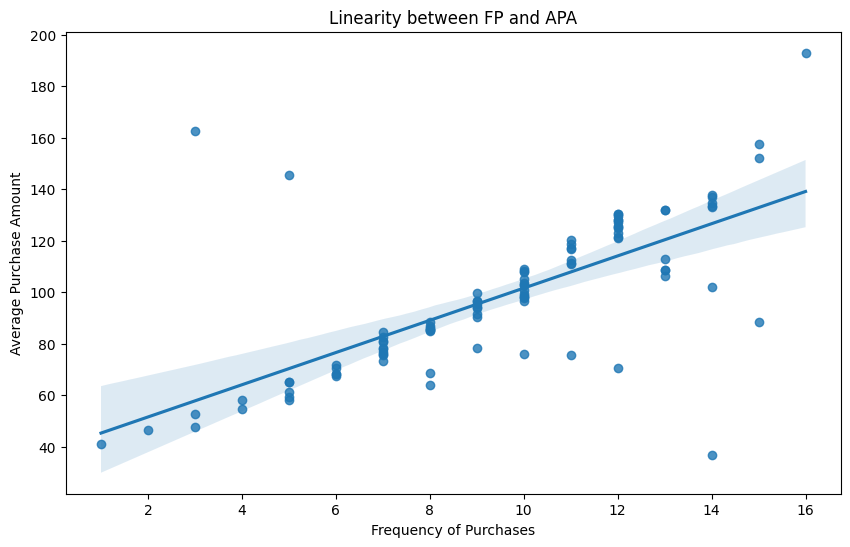

In [60]:
plt.figure(figsize =(10,6))
sns.regplot(x = 'Frequency_of_Purchases', y = 'Average_Purchase_Amount', data = preprocessed_data)
plt.title('Linearity between FP and APA')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Average Purchase Amount')
plt.show()

In [63]:
from scipy.stats import pearsonr
purchase_frequency = preprocessed_data['Frequency_of_Purchases']
purchase_amount = preprocessed_data['Average_Purchase_Amount']
corr,p_value = pearsonr(purchase_frequency, purchase_amount)
print('Pearson correlation coefficient:', corr)
print('P-value:', p_value)
if p_value < 0.05:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

Pearson correlation coefficient: 0.7039911501130026
P-value: 6.176786543555055e-16
Reject the null hypothesis


In [65]:
import statsmodels.api as sm
 
x = preprocessed_data['Frequency_of_Purchases']
y = preprocessed_data['Average_Purchase_Amount']
x_constant = sm.add_constant(x)
model = sm.OLS(y, x_constant).fit()
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     Average_Purchase_Amount   R-squared:                       0.496
Model:                                 OLS   Adj. R-squared:                  0.490
Method:                      Least Squares   F-statistic:                     94.33
Date:                     Mon, 29 Jun 2026   Prob (F-statistic):           6.18e-16
Time:                             13:08:59   Log-Likelihood:                -435.04
No. Observations:                       98   AIC:                             874.1
Df Residuals:                           96   BIC:                             879.3
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [69]:
predicted_Apa = 39.0765 + (6.2551 * 70)
print(predicted_Apa)

476.9335
